# Test on UCF101, Kinetics400 and ETRI-Activity3D

## Run evaluation

In [1]:
# Copyright (c) OpenMMLab. All rights reserved.
import os
import os.path as osp
import warnings

import mmcv
import torch
from mmcv import Config
from mmcv.cnn import fuse_conv_bn
from mmcv.fileio.io import file_handlers
from mmcv.runner import get_dist_info, init_dist, load_checkpoint
from mmcv.runner.fp16_utils import wrap_fp16_model

from mmaction.datasets import build_dataloader, build_dataset
from mmaction.models import build_model
from mmaction.utils import (build_ddp, build_dp, default_device,
                            register_module_hooks, setup_multi_processes)

# TODO import test functions from mmcv and delete them from mmaction2
try:
    from mmcv.engine import multi_gpu_test, single_gpu_test
except (ImportError, ModuleNotFoundError):
    warnings.warn(
        'DeprecationWarning: single_gpu_test, multi_gpu_test, '
        'collect_results_cpu, collect_results_gpu from mmaction2 will be '
        'deprecated. Please install mmcv through master branch.')
    from mmaction.apis import multi_gpu_test, single_gpu_test


def turn_off_pretrained(cfg):
    # recursively find all pretrained in the model config,
    # and set them None to avoid redundant pretrain steps for testing
    if 'pretrained' in cfg:
        cfg.pretrained = None

    # recursively turn off pretrained value
    for sub_cfg in cfg.values():
        if isinstance(sub_cfg, dict):
            turn_off_pretrained(sub_cfg)


def inference_pytorch(args, cfg, distributed, data_loader):
    """Get predictions by pytorch models."""
    if args.average_clips is not None:
        # You can set average_clips during testing, it will override the
        # original setting
        if cfg.model.get('test_cfg') is None and cfg.get('test_cfg') is None:
            cfg.model.setdefault('test_cfg',
                                 dict(average_clips=args.average_clips))
        else:
            if cfg.model.get('test_cfg') is not None:
                cfg.model.test_cfg.average_clips = args.average_clips
            else:
                cfg.test_cfg.average_clips = args.average_clips

    # remove redundant pretrain steps for testing
    turn_off_pretrained(cfg.model)

    # build the model and load checkpoint
    model = build_model(
        cfg.model, train_cfg=None, test_cfg=cfg.get('test_cfg'))

    if len(cfg.module_hooks) > 0:
        register_module_hooks(model, cfg.module_hooks)

    fp16_cfg = cfg.get('fp16', None)
    if fp16_cfg is not None:
        wrap_fp16_model(model)
    load_checkpoint(model, args.checkpoint, map_location='cpu')

    if args.fuse_conv_bn:
        model = fuse_conv_bn(model)

    if not distributed:
        model = build_dp(
            model, default_device, default_args=dict(device_ids=cfg.gpu_ids))
        outputs = single_gpu_test(model, data_loader)
    else:
        model = build_ddp(
            model,
            default_device,
            default_args=dict(
                device_ids=[int(os.environ['LOCAL_RANK'])],
                broadcast_buffers=False))
        outputs = multi_gpu_test(model, data_loader, args.tmpdir,
                                 args.gpu_collect)

    return outputs


def inference_tensorrt(ckpt_path, distributed, data_loader, batch_size):
    """Get predictions by TensorRT engine.

    For now, multi-gpu mode and dynamic tensor shape are not supported.
    """
    assert not distributed, \
        'TensorRT engine inference only supports single gpu mode.'
    import tensorrt as trt
    from mmcv.tensorrt.tensorrt_utils import (torch_device_from_trt,
                                              torch_dtype_from_trt)

    # load engine
    with trt.Logger() as logger, trt.Runtime(logger) as runtime:
        with open(ckpt_path, mode='rb') as f:
            engine_bytes = f.read()
        engine = runtime.deserialize_cuda_engine(engine_bytes)

    # For now, only support fixed input tensor
    cur_batch_size = engine.get_binding_shape(0)[0]
    assert batch_size == cur_batch_size, \
        ('Dataset and TensorRT model should share the same batch size, '
         f'but get {batch_size} and {cur_batch_size}')

    context = engine.create_execution_context()

    # get output tensor
    dtype = torch_dtype_from_trt(engine.get_binding_dtype(1))
    shape = tuple(context.get_binding_shape(1))
    device = torch_device_from_trt(engine.get_location(1))
    output = torch.empty(
        size=shape, dtype=dtype, device=device, requires_grad=False)

    # get predictions
    results = []
    dataset = data_loader.dataset
    prog_bar = mmcv.ProgressBar(len(dataset))
    for data in data_loader:
        bindings = [
            data['imgs'].contiguous().data_ptr(),
            output.contiguous().data_ptr()
        ]
        context.execute_async_v2(bindings,
                                 torch.cuda.current_stream().cuda_stream)
        results.extend(output.cpu().numpy())
        batch_size = len(next(iter(data.values())))
        for _ in range(batch_size):
            prog_bar.update()
    return results


def inference_onnx(ckpt_path, distributed, data_loader, batch_size):
    """Get predictions by ONNX.

    For now, multi-gpu mode and dynamic tensor shape are not supported.
    """
    assert not distributed, 'ONNX inference only supports single gpu mode.'

    import onnx
    import onnxruntime as rt

    # get input tensor name
    onnx_model = onnx.load(ckpt_path)
    input_all = [node.name for node in onnx_model.graph.input]
    input_initializer = [node.name for node in onnx_model.graph.initializer]
    net_feed_input = list(set(input_all) - set(input_initializer))
    assert len(net_feed_input) == 1

    # For now, only support fixed tensor shape
    input_tensor = None
    for tensor in onnx_model.graph.input:
        if tensor.name == net_feed_input[0]:
            input_tensor = tensor
            break
    cur_batch_size = input_tensor.type.tensor_type.shape.dim[0].dim_value
    assert batch_size == cur_batch_size, \
        ('Dataset and ONNX model should share the same batch size, '
         f'but get {batch_size} and {cur_batch_size}')

    # get predictions
    sess = rt.InferenceSession(ckpt_path)
    results = []
    dataset = data_loader.dataset
    prog_bar = mmcv.ProgressBar(len(dataset))
    for data in data_loader:
        imgs = data['imgs'].cpu().numpy()
        onnx_result = sess.run(None, {net_feed_input[0]: imgs})[0]
        results.extend(onnx_result)
        batch_size = len(next(iter(data.values())))
        for _ in range(batch_size):
            prog_bar.update()
    return results

def test(args, cfg):
    # set multi-process settings
    setup_multi_processes(cfg)

    # Load output_config from cfg
    output_config = cfg.get('output_config', {})
    if args.out:
        # Overwrite output_config from args.out
        output_config = Config._merge_a_into_b(
            dict(out=args.out), output_config)

    # Load eval_config from cfg
    eval_config = cfg.get('eval_config', {})
    if args.eval:
        # Overwrite eval_config from args.eval
        eval_config = Config._merge_a_into_b(
            dict(metrics=args.eval), eval_config)
    if args.eval_options:
        # Add options from args.eval_options
        eval_config = Config._merge_a_into_b(args.eval_options, eval_config)

    assert output_config or eval_config, \
        ('Please specify at least one operation (save or eval the '
            'results) with the argument "--out" or "--eval"')

    dataset_type = cfg.data.test.type
    if output_config.get('out', None):
        if 'output_format' in output_config:
            # ugly workround to make recognition and localization the same
            warnings.warn(
                'Skip checking `output_format` in localization task.')
        else:
            out = output_config['out']
            # make sure the dirname of the output path exists
            mmcv.mkdir_or_exist(osp.dirname(out))
            _, suffix = osp.splitext(out)
            if dataset_type == 'AVADataset':
                assert suffix[1:] == 'csv', ('For AVADataset, the format of '
                                                'the output file should be csv')
            else:
                assert suffix[1:] in file_handlers, (
                    'The format of the output '
                    'file should be json, pickle or yaml')

    # set cudnn benchmark
    if cfg.get('cudnn_benchmark', False):
        torch.backends.cudnn.benchmark = True
    cfg.data.test.test_mode = True

    # init distributed env first, since logger depends on the dist info.
    if args.launcher == 'none':
        distributed = False
    else:
        distributed = True
        init_dist(args.launcher, **cfg.dist_params)

    # The flag is used to register module's hooks
    cfg.setdefault('module_hooks', [])

    # build the dataloader
    dataset = build_dataset(cfg.data.test, dict(test_mode=True))
    dataloader_setting = dict(
        videos_per_gpu=cfg.data.get('videos_per_gpu', 1),
        workers_per_gpu=cfg.data.get('workers_per_gpu', 1),
        dist=distributed,
        shuffle=False)
    dataloader_setting = dict(dataloader_setting,
                                **cfg.data.get('test_dataloader', {}))
    data_loader = build_dataloader(dataset, **dataloader_setting)

    if args.tensorrt:
        outputs = inference_tensorrt(args.checkpoint, distributed, data_loader,
                                        dataloader_setting['videos_per_gpu'])
    elif args.onnx:
        outputs = inference_onnx(args.checkpoint, distributed, data_loader,
                                    dataloader_setting['videos_per_gpu'])
    else:
        outputs = inference_pytorch(args, cfg, distributed, data_loader)

    rank, _ = get_dist_info()
    if rank == 0:
        if output_config.get('out', None):
            out = output_config['out']
            print(f'\nwriting results to {out}')
            dataset.dump_results(outputs, **output_config)
        if eval_config:
            eval_res = dataset.evaluate(outputs, **eval_config)
            for name, val in eval_res.items():
                print(f'{name}: {val:.04f}')

In [2]:
def prepare_config(cfg, pre_trained_model, dataset_name, dataset_dir, logs_dir, n_classes, k):

    # Modify dataset type and path
    if k is not None:
        prepare_config_data_k(cfg, dataset_name, dataset_dir, k)
    else:
        prepare_config_data(cfg, dataset_name, dataset_dir)

    # The flag is used to determine whether it is omnisource training
    cfg.setdefault('omnisource', False)
    # Modify num classes of the model in cls_head
    cfg.model.cls_head.num_classes = n_classes
    # We can use the pre-trained TSN model
    cfg.load_from = pre_trained_model

    # Set up working dir to save files and logs.
    cfg.work_dir = logs_dir

    # The original learning rate (LR) is set for 8-GPU training.
    # We divide it by 8 since we only use one GPU.
    cfg.data.videos_per_gpu = 2
    cfg.data.workers_per_gpu = 4
    cfg.optimizer.lr = cfg.optimizer.lr / 8
    cfg.total_epochs = 10

    # We can set the checkpoint saving interval to reduce the storage cost
    cfg.checkpoint_config.interval = 10
    # We can set the log print interval to reduce the times of printing log
    cfg.log_config.interval = 5

    # Set seed thus the results are more reproducible
    cfg.seed = 777
    # set_random_seed(777, deterministic=False)
    cfg.gpu_ids = range(1)

    # Save the best
    cfg.evaluation.save_best=None

    # We can initialize the logger for training and have a look
    # at the final config used for training
    # print(f'Config:\n{cfg.pretty_text}')

def prepare_config_data_k(cfg, dataset_name, dataset_dir, k):

    cfg.dataset_type = 'VideoDataset'
    cfg.data_root = dataset_dir + '/videos'
    cfg.data_root_val =  dataset_dir + '/videos'
    cfg.ann_file_train =  dataset_dir + '/' + dataset_name + '_' + str(k) + '_train_video.txt'
    cfg.ann_file_val =  dataset_dir + '/' + dataset_name  + '_' + str(k) + '_test_video.txt'
    cfg.ann_file_test =  dataset_dir + '/' + dataset_name + '_' + str(k) + '_test_video.txt'

    cfg.data.train.type = 'VideoDataset'
    cfg.data.train.ann_file = dataset_dir + '/' + dataset_name + '_' + str(k) + '_train_video.txt'
    cfg.data.train.data_prefix = cfg.data_root

    cfg.data.val.type = 'VideoDataset'
    cfg.data.val.ann_file =dataset_dir + '/' + dataset_name + '_' + str(k) + '_test_video.txt'
    cfg.data.val.data_prefix = cfg.data_root

    cfg.data.test.type = 'VideoDataset'
    cfg.data.test.ann_file = dataset_dir + '/' + dataset_name + '_' + str(k) + '_test_video.txt'
    cfg.data.test.data_prefix = cfg.data_root

def prepare_config_data(cfg, dataset_name, dataset_dir):
    
    cfg.dataset_type = 'VideoDataset'
    cfg.data_root = dataset_dir + '/videos'
    cfg.data_root_val =  dataset_dir + '/videos'
    cfg.ann_file_train =  dataset_dir + '/' + dataset_name + '_train_video.txt'
    cfg.ann_file_val =  dataset_dir + '/' + dataset_name + '_test_video.txt'
    cfg.ann_file_test =  dataset_dir + '/' + dataset_name + '_test_video.txt'

    cfg.data.train.type = 'VideoDataset'
    cfg.data.train.ann_file = dataset_dir + '/' + dataset_name + '_train_video.txt'
    cfg.data.train.data_prefix = cfg.data_root

    cfg.data.val.type = 'VideoDataset'
    cfg.data.val.ann_file =dataset_dir + '/' + dataset_name + '_test_video.txt'
    cfg.data.val.data_prefix = cfg.data_root

    cfg.data.test.type = 'VideoDataset'
    cfg.data.test.ann_file = dataset_dir + '/' + dataset_name + '_test_video.txt'
    cfg.data.test.data_prefix = cfg.data_root


class dotdict(dict):
    """dot.notation access to dictionary attributes"""
    __getattr__ = dict.get
    __setattr__ = dict.__setitem__
    __delattr__ = dict.__delitem__

In [3]:
root = 'C:/Users/Xavi/OneDrive - Universitat de les Illes Balears/Doctorat/Video explanations paper/TFM'
models = ["TimeSformer", "TANet", "TPN"]
datasets = ["EtriActivity3D", "Kinetics400", "UCF101"]
datasets_folder = {
    'EtriActivity3D': 'Z:/Xavi/EtriActivity3D',
    'Kinetics400': 'Z:/Xavi/Kinetics400',
    'UCF101': 'Z:/Xavi/UCF101'}

# For configs, we use the same as for EtriActivity3D
configs = {
            'TimeSformer': root+'/configs/EtriActivity3D/timesformer_divST_8x32x1_15e_kinetics400_rgb.py',
            'TANet': root+'/configs/EtriActivity3D/tanet_r50_dense_1x1x8_100e_kinetics400_rgb.py',
            'TPN': root+'/configs/EtriActivity3D/tpn_imagenet_pretrained_slowonly_r50_8x8x1_150e_kinetics_rgb.py'
            }

# We use pre-trained weights on Kinetics400
weights = {
            'TimeSformer': root+'/weights/kinetics400/timesformer_divST_8x32x1_15e_kinetics400_rgb-3f8e5d03.pth',
            'TANet': root+'/weights/kinetics400/tanet_r50_dense_1x1x8_100e_kinetics400_rgb_20210219-032c8e94.pth',
            'TPN': root+'/weights/kinetics400/tpn_imagenet_pretrained_slowonly_r50_8x8x1_150e_kinetics_rgb-44362b55.pth'
            }

### UCF101 and EtriActivity3D with K-cross validation

In [ ]:
dataset_dirs = [datasets_folder['UCF101'], datasets_folder['EtriActivity3D']]
dataset_names = ['UCF101', 'EtriActivity3D']
n_classes = [101, 55]
model_names = ['TimeSformer', 'TPN', 'TANet']

# Iterate over the datasets
for dataset_name, dataset_dir, n_classes in zip(dataset_names, dataset_dirs, n_classes):
    print(f'Processing dataset {dataset_name} with {n_classes} classes')

    # Logs folder for each dataset
    logs_dir_root = dataset_dir + '/' + 'training'

    # Iterate over the models
    for model in model_names:
        print(f'Processing model {model}')

        # Create logs folder for each model
        logs_dir = logs_dir_root + '/' + model
        
        # Iterate over the folds
        for k in range(1, 6):
            print(f'Processing fold {k}')

            # Logs folder for each iteration
            logs_dir_k = logs_dir + '/' + str(k)

            # For each fold, prepare the config file and train the model
            checkpoint = logs_dir_k + '/epoch_10.pth'
            out_file = logs_dir_k + '/results_test.json'
            args = dotdict({'checkpoint': checkpoint, 'out': out_file, 'gpu_collect': True, 'launcher': 'none'})

            # Prepare the config file
            cfg = Config.fromfile(configs[model])
            prepare_config(cfg, checkpoint, dataset_name, dataset_dir, logs_dir_k, n_classes, k)
            if model == 'TPN':
                cfg.model.neck.aux_head_cfg.out_channels = n_classes
            
            if not os.path.exists(out_file):

                # DEFUALT SETTINGS AND OPERATIONS
                test(args, cfg)

### Kinetics400 test

In [9]:
dataset_dir = datasets_folder['Kinetics400']
dataset_name = 'Kinetics400'
n_classes = 400
model_names = ['TimeSformer', 'TPN', 'TANet']

# Logs folder
logs_dir_root = dataset_dir + '/' + 'training'
if not os.path.exists(logs_dir_root):
    os.makedirs(logs_dir_root)

# Iterate over the models
for model in model_names:
    print(f'Processing model {model}')

    # Create logs folder for each model
    logs_dir = logs_dir_root + '/' + model
    if not os.path.exists(logs_dir):
        os.makedirs(logs_dir)

    # For each model, prepare the config file and train the model
    checkpoint = weights[model]
    out_file = logs_dir + '/results_test.json'
    args = dotdict({'checkpoint': checkpoint, 'out': out_file, 'gpu_collect': True, 'launcher': 'none'})

    # Prepare the config file
    cfg = Config.fromfile(configs[model])
    prepare_config(cfg, checkpoint, dataset_name, dataset_dir, logs_dir, n_classes, None)
    if model == 'TPN':
        cfg.model.neck.aux_head_cfg.out_channels = n_classes
    
    if not os.path.exists(out_file):

        # DEFUALT SETTINGS AND OPERATIONS
        test(args, cfg)

Processing model TimeSformer
Config:
checkpoint_config = dict(interval=10)
log_config = dict(interval=5, hooks=[dict(type='TextLoggerHook')])
dist_params = dict(backend='nccl')
log_level = 'INFO'
load_from = 'C:/Users/Xavi/OneDrive - Universitat de les Illes Balears/Doctorat/Video explanations paper/TFM/weights/kinetics400/timesformer_divST_8x32x1_15e_kinetics400_rgb-3f8e5d03.pth'
resume_from = None
workflow = [('train', 1)]
opencv_num_threads = 0
mp_start_method = 'fork'
model = dict(
    type='Recognizer3D',
    backbone=dict(
        type='TimeSformer',
        pretrained=
        'https://download.openmmlab.com/mmaction/recognition/timesformer/vit_base_patch16_224.pth',
        num_frames=8,
        img_size=224,
        patch_size=16,
        embed_dims=768,
        in_channels=3,
        dropout_ratio=0.0,
        transformer_layers=None,
        attention_type='divided_space_time',
        norm_cfg=dict(type='LN', eps=1e-06)),
    cls_head=dict(type='TimeSformerHead', num_classe

d:\xavi\tfm\mmaction2\mmaction\utils\setup_env.py:33: UserWarning: Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed.
  f'Setting OMP_NUM_THREADS environment variable for each process '
d:\xavi\tfm\mmaction2\mmaction\utils\setup_env.py:43: UserWarning: Setting MKL_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed.
  f'Setting MKL_NUM_THREADS environment variable for each process '


load checkpoint from local path: C:/Users/Xavi/OneDrive - Universitat de les Illes Balears/Doctorat/Video explanations paper/TFM/weights/kinetics400/timesformer_divST_8x32x1_15e_kinetics400_rgb-3f8e5d03.pth
[>>>>>>>>>>>>>>>>>>>>>>>] 34778/34778, 14.5 task/s, elapsed: 2394s, ETA:     0s
writing results to Z:/Xavi/Kinetics400/training/TimeSformer/results_test.json
Processing model TPN
Config:
model = dict(
    type='Recognizer3D',
    backbone=dict(
        type='ResNet3dSlowOnly',
        depth=50,
        pretrained='torchvision://resnet50',
        lateral=False,
        out_indices=(2, 3),
        conv1_kernel=(1, 7, 7),
        conv1_stride_t=1,
        pool1_stride_t=1,
        inflate=(0, 0, 1, 1),
        norm_eval=False),
    neck=dict(
        type='TPN',
        in_channels=(1024, 2048),
        out_channels=1024,
        spatial_modulation_cfg=dict(
            in_channels=(1024, 2048), out_channels=2048),
        temporal_modulation_cfg=dict(downsample_scales=(8, 8)),
      

d:\ProgramData\Anaconda3\envs\open-mmlab\lib\site-packages\torch\nn\functional.py:878: UserWarning: Note that order of the arguments: ceil_mode and return_indices will changeto match the args list in nn.MaxPool3d in a future release.
  warnings.warn("Note that order of the arguments: ceil_mode and return_indices will change"


[>>>>>>>>>>>>>>>>>>>>>>>] 34778/34778, 2.2 task/s, elapsed: 15708s, ETA:     0s
writing results to Z:/Xavi/Kinetics400/training/TPN/results_test.json
Processing model TANet
Config:
checkpoint_config = dict(interval=10)
log_config = dict(interval=5, hooks=[dict(type='TextLoggerHook')])
dist_params = dict(backend='nccl')
log_level = 'INFO'
load_from = 'C:/Users/Xavi/OneDrive - Universitat de les Illes Balears/Doctorat/Video explanations paper/TFM/weights/kinetics400/tanet_r50_dense_1x1x8_100e_kinetics400_rgb_20210219-032c8e94.pth'
resume_from = None
workflow = [('train', 1)]
opencv_num_threads = 0
mp_start_method = 'fork'
model = dict(
    type='Recognizer2D',
    backbone=dict(
        type='TANet',
        pretrained='torchvision://resnet50',
        depth=50,
        num_segments=8,
        tam_cfg=dict()),
    cls_head=dict(
        type='TSMHead',
        num_classes=400,
        in_channels=2048,
        spatial_type='avg',
        consensus=dict(type='AvgConsensus', dim=1),
      

## Compute metrics

In [4]:
import mmcv
from mmcv import Config
from mmaction.datasets import build_dataset
from matplotlib import pyplot as plt

import numpy as np

In [5]:
def get_kwargs(cfg):
    eval_kwargs = cfg.get('evaluation', {}).copy()
    # hard-code way to remove EvalHook args
    for key in [
            'interval', 'tmpdir', 'start', 'gpu_collect', 'save_best', 'rule',
            'by_epoch'
    ]:
        eval_kwargs.pop(key, None)
    return eval_kwargs


def print_metric(cfg, metric, outputs, dataset):
    kwargs = {}
    eval_kwargs = get_kwargs(cfg)
    eval_kwargs.update(dict(metrics=metric, **kwargs))
    return dataset.evaluate(outputs, **eval_kwargs)

In [6]:
metrics = ['top_k_accuracy', 'mean_class_accuracy', 'class_accuracy']
metrics2 = ['top1_acc', 'top5_acc', 'mean_class_accuracy', 'class_accuracy']

# Dictionary to store the results
results = {}

### UCF101 and EtriActivity3D

In [8]:
dataset_dirs = [datasets_folder['UCF101'], datasets_folder['EtriActivity3D']]
dataset_names = ['UCF101', 'EtriActivity3D']
n_classes = [101, 55]
model_names = ['TimeSformer', 'TPN', 'TANet']

# Iterate over the datasets
for dataset_name, dataset_dir, n_classes in zip(dataset_names, dataset_dirs, n_classes):
    print(f'Processing dataset {dataset_name} with {n_classes} classes')

    # Logs folder for each dataset
    logs_dir_root = dataset_dir + '/' + 'training'

    # Add dataset to results dictionary if it does not exist
    if dataset_name not in results:
        results[dataset_name] = {}

    # Iterate over the models
    for model in model_names:
        print(f'Processing model {model}')

        # Create logs folder for each model
        logs_dir = logs_dir_root + '/' + model

        # Add model to results dictionary if it does not exist
        if model not in results[dataset_name]:
            results[dataset_name][model] = {}
        
        # Iterate over the folds
        for k in range(1, 6):
            print(f'Processing fold {k}')

            # Logs folder for each iteration
            logs_dir_k = logs_dir + '/' + str(k)

            # Prepare the dataset
            cfg = Config.fromfile(configs[model])
            prepare_config(cfg, None, dataset_name, dataset_dir, logs_dir_k, n_classes, k)
            dataset = build_dataset(cfg.data.test)

            # For each fold, prepare the config file and train the model
            out_file = logs_dir_k + '/results_test.json'
            outputs = mmcv.load(out_file)
            
            # Add fold to results dictionary if it does not exist
            if k not in results[dataset_name][model]:
                results[dataset_name][model][k] = {}

            # Iterate over the metrics
            for metric in metrics:
                results[dataset_name][model][k].update(print_metric(cfg, metric, outputs, dataset))
        
        # Calculate the mean of the folds
        results[dataset_name][model]['mean'] = {}
        for metric in metrics2:
            results[dataset_name][model]['mean'][metric] = np.mean(np.array([results[dataset_name][model][k][metric] for k in range(1, 6)]), axis=0)
            
    # Calculate the mean of the models
    results[dataset_name]['mean'] = {}
    for metric in metrics2:
        results[dataset_name]['mean'][metric] = np.mean(np.array([results[dataset_name][model]['mean'][metric] for model in model_names]), axis=0)

Processing dataset UCF101 with 101 classes
Processing model TimeSformer
Processing fold 1
Config:
checkpoint_config = dict(interval=10)
log_config = dict(interval=5, hooks=[dict(type='TextLoggerHook')])
dist_params = dict(backend='nccl')
log_level = 'INFO'
load_from = None
resume_from = None
workflow = [('train', 1)]
opencv_num_threads = 0
mp_start_method = 'fork'
model = dict(
    type='Recognizer3D',
    backbone=dict(
        type='TimeSformer',
        pretrained=
        'https://download.openmmlab.com/mmaction/recognition/timesformer/vit_base_patch16_224.pth',
        num_frames=8,
        img_size=224,
        patch_size=16,
        embed_dims=768,
        in_channels=3,
        dropout_ratio=0.0,
        transformer_layers=None,
        attention_type='divided_space_time',
        norm_cfg=dict(type='LN', eps=1e-06)),
    cls_head=dict(type='TimeSformerHead', num_classes=101, in_channels=768),
    train_cfg=None,
    test_cfg=dict(average_clips='prob'))
dataset_type = 'VideoDat

### Kinetics 400

In [10]:
dataset_dir = datasets_folder['Kinetics400']
dataset_name = 'Kinetics400'
n_classes = 400
model_names = ['TimeSformer', 'TPN', 'TANet']

# Logs folder
logs_dir_root = dataset_dir + '/' + 'training'
if not os.path.exists(logs_dir_root):
    os.makedirs(logs_dir_root)

# Add dataset to results dictionary if it does not exist
if dataset_name not in results:
    results[dataset_name] = {}

# Iterate over the models
for model in model_names:
    print(f'Processing model {model}')

    # Create logs folder for each model
    logs_dir = logs_dir_root + '/' + model
    if not os.path.exists(logs_dir):
        os.makedirs(logs_dir)

    # For each model, prepare the config file and train the model
    out_file = logs_dir + '/results_test.json'
    outputs = mmcv.load(out_file)

    # Prepare the config file
    cfg = Config.fromfile(configs[model])
    prepare_config(cfg, None, dataset_name, dataset_dir, logs_dir, n_classes, None)
    dataset = build_dataset(cfg.data.test)

    # Add model to results dictionary if it does not exist
    if model not in results[dataset_name]:
        results[dataset_name][model] = { 'mean': {} }

    # Iterate over the metrics
    for metric in metrics:
        results[dataset_name][model]['mean'].update(print_metric(cfg, metric, outputs, dataset))

# Calculate the mean of the models
results[dataset_name]['mean'] = {}
for metric in metrics2:
    results[dataset_name]['mean'][metric] = np.mean(np.array([results[dataset_name][model]['mean'][metric] for model in model_names]), axis=0)

Processing model TimeSformer
Config:
checkpoint_config = dict(interval=10)
log_config = dict(interval=5, hooks=[dict(type='TextLoggerHook')])
dist_params = dict(backend='nccl')
log_level = 'INFO'
load_from = None
resume_from = None
workflow = [('train', 1)]
opencv_num_threads = 0
mp_start_method = 'fork'
model = dict(
    type='Recognizer3D',
    backbone=dict(
        type='TimeSformer',
        pretrained=
        'https://download.openmmlab.com/mmaction/recognition/timesformer/vit_base_patch16_224.pth',
        num_frames=8,
        img_size=224,
        patch_size=16,
        embed_dims=768,
        in_channels=3,
        dropout_ratio=0.0,
        transformer_layers=None,
        attention_type='divided_space_time',
        norm_cfg=dict(type='LN', eps=1e-06)),
    cls_head=dict(type='TimeSformerHead', num_classes=400, in_channels=768),
    train_cfg=None,
    test_cfg=dict(average_clips='prob'))
dataset_type = 'VideoDataset'
data_root = 'Z:/Xavi/Kinetics400/videos'
data_root_val 

## Charts

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [12]:
model_names = ['TimeSformer', 'TPN', 'TANet']
datasets = ["EtriActivity3D", "Kinetics400", "UCF101"]

In [13]:
def grouped_bar(ax, x_labels, legend_and_y_values, y_title, title, y_lim=None, width=0.25, multiplier=0, padding=3, show_values=True, leg_loc='upper left', mode='bar', leg_grid='y'):
    
    x = np.arange(len(x_labels))  # the label locations
    legend_labels = []
    legend_colors = []

    for (label, value), color in zip(legend_and_y_values.items(), plt.rcParams['axes.prop_cycle'].by_key()['color']*10):
        offset = width * multiplier
        if mode == 'bar':
            rects = ax.bar(x + offset, value, width, label=label)
        elif mode == 'box':
            rects = ax.boxplot(value, positions=x + offset, vert=True, patch_artist=True, labels=[value]*len(models), widths=width)
            for patch in rects['boxes']:
                patch.set_facecolor(color)
            for median in rects['medians']:
                median.set_color('black')
            legend_labels.append(label)
            legend_colors.append(color)
        if show_values:
            ax.bar_label(rects, padding=padding)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.grid(axis = leg_grid, linestyle = 'dotted')
    ax.set_ylabel(y_title)
    ax.set_title(title, fontsize = 22)
    ax.set_yticks(np.arange(y_lim[0], y_lim[1], (round(y_lim[1]-y_lim[0]))/10))
    ax.set_xticks(x + width, x_labels, rotation=90)
    if mode == 'bar':
        if leg_loc == 'outside':
            box = ax.get_position()
            ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        else:
            ax.legend(loc=leg_loc)
    elif mode == 'box':
        if leg_loc == 'outside':
            box = ax.get_position()
            ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
            leg = ax.legend(loc='center left', handles=[mpatches.Patch(color=color, label=label) for color, label in zip(legend_colors, legend_labels)], bbox_to_anchor=(1, 0.5))
        else:
            leg = ax.legend(loc=leg_loc, handles=[mpatches.Patch(color=color, label=label) for color, label in zip(legend_colors, legend_labels)])
        
    if y_lim is not None:
        ax.set_ylim(y_lim[0], y_lim[1])

### Boxplots of K-Cross Validation

In [18]:
metric = 'top1_acc'
metric_name = 'Accuracy'
legend_and_y_values = {}

for dataset in ["EtriActivity3D", "UCF101"]:
    data = np.zeros(shape=[5,3])
    for i, model_name in enumerate(model_names):
        data[:,i] = np.array([results[dataset][model_name][i][metric] for i in range(1, 6)])
    legend_and_y_values[dataset] = data

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


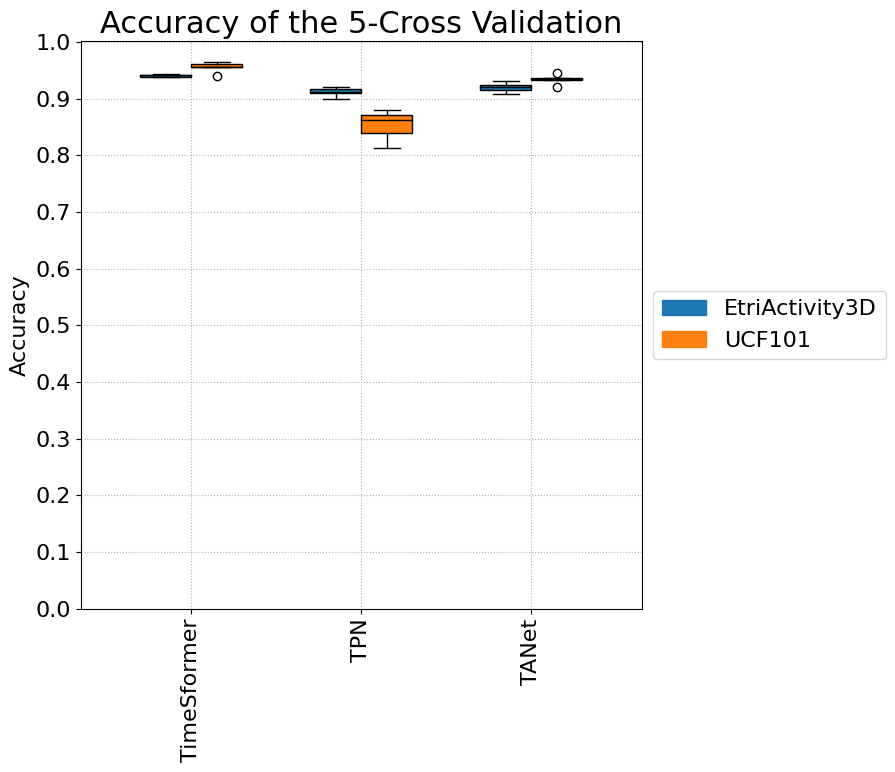

In [19]:
plt.rcParams['font.size'] = 16
fig, ax = plt.subplots(figsize=(8,8))
grouped_bar(ax, model_names, legend_and_y_values, y_title=metric_name, title='Accuracy of the 5-Cross Validation', leg_grid='both', mode='box', y_lim=(0, 1.001), width = 0.3, multiplier = 0.5, padding=0, show_values=False, leg_loc='outside')
plt.tight_layout()
# plt.savefig('Z:/Xavi/Muderi/charts/final/muderi-f1s boxplot.png')
plt.show()

In [27]:
legend_and_y_values = {}
for dataset in ["EtriActivity3D", "UCF101"]:
    legend_and_y_values[dataset] = {}
    for i, model_name in enumerate(model_names):
        legend_and_y_values[dataset][model_name] = np.mean([results[dataset][model_name][i][metric] for i in range(1, 6)])
legend_and_y_values

{'EtriActivity3D': {'TimeSformer': 0.94016725148469,
  'TPN': 0.9115149251750916,
  'TANet': 0.9198014848238418},
 'UCF101': {'TimeSformer': 0.9552082820477645,
  'TPN': 0.852761200465143,
  'TANet': 0.9337719948531831}}

### Average accuracy by model and dataset

In [102]:
metric = 'top1_acc'
metric_name = 'Accuracy'
legend_and_y_values = {}

for dataset in datasets:
    legend_and_y_values[dataset] = [results[dataset][model_name]['mean'][metric] for model_name in model_names]

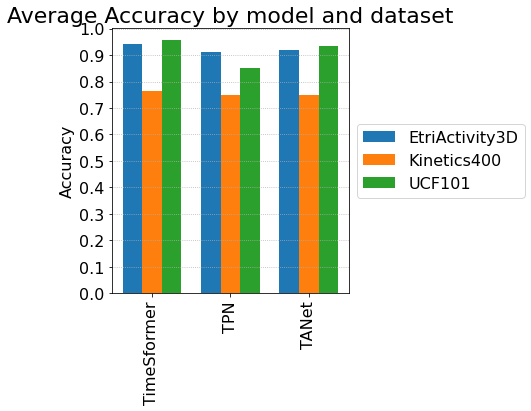

In [103]:
plt.rcParams['font.size'] = 16
fig, ax = plt.subplots(figsize=(6,6))
grouped_bar(ax, model_names, legend_and_y_values, y_title=metric_name, title='Average Accuracy by model and dataset', y_lim=(0, 1.001), width = 0.25, multiplier = 0, padding=20, show_values=False, leg_loc='outside')
plt.tight_layout()
# plt.savefig('Z:/Xavi/Muderi/charts/final/muderi-f1s.png')
plt.show()

### Class accuracy (averaging models by dataset)

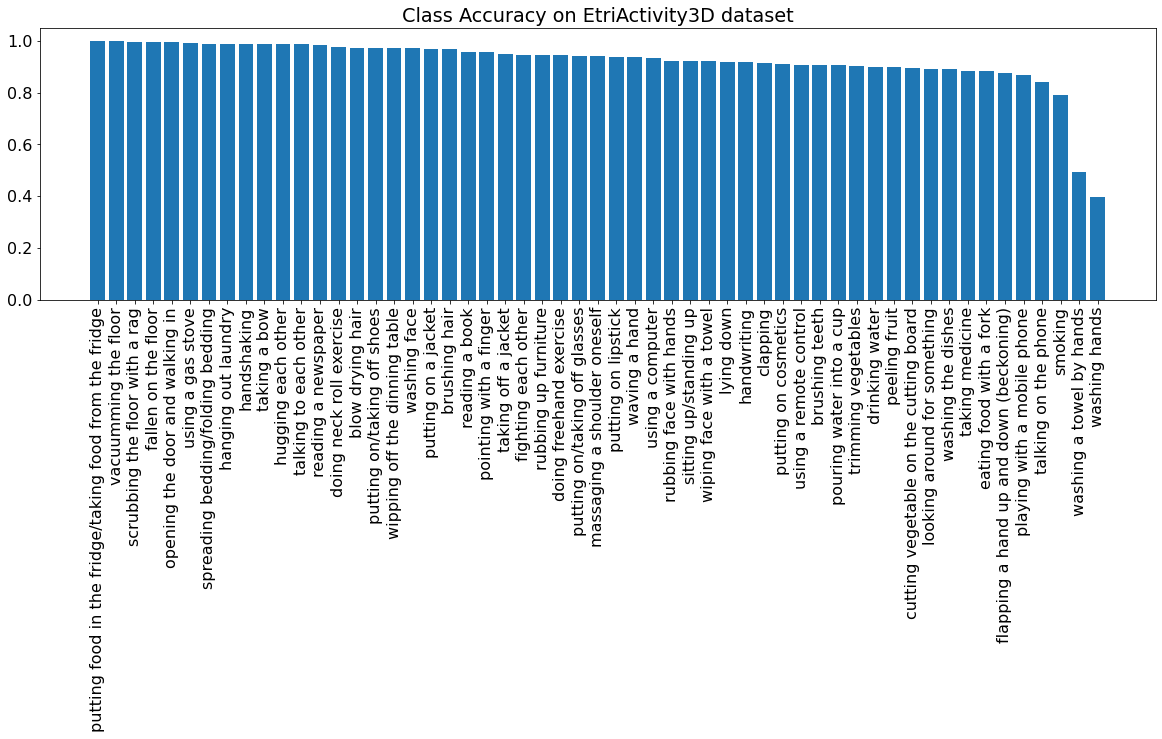

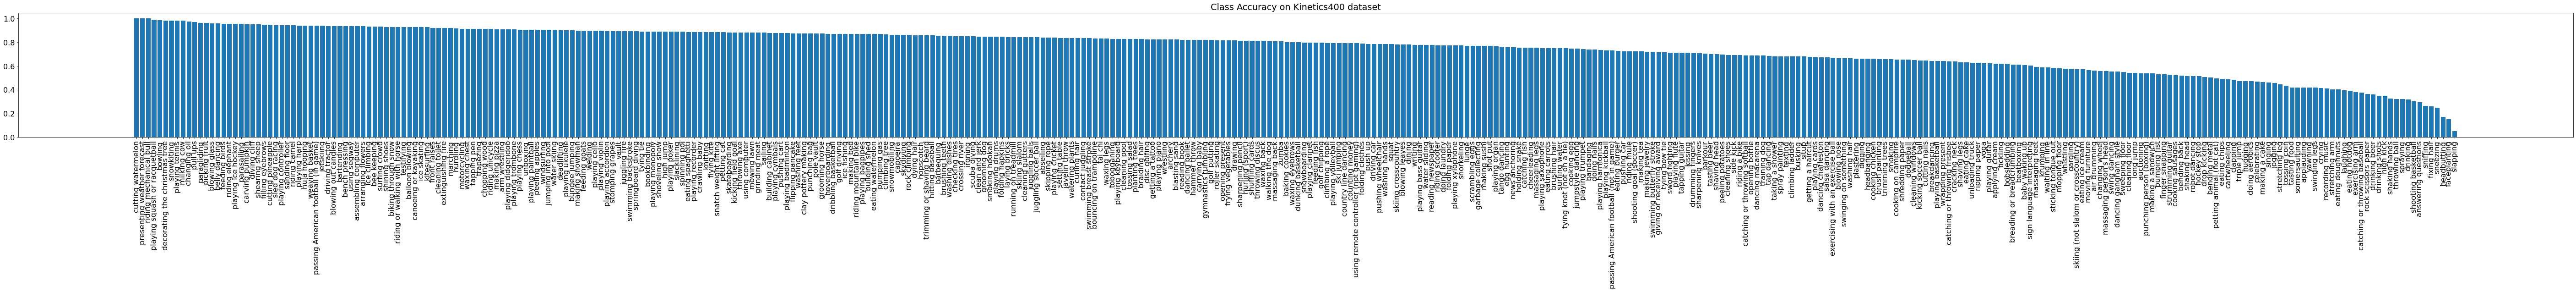

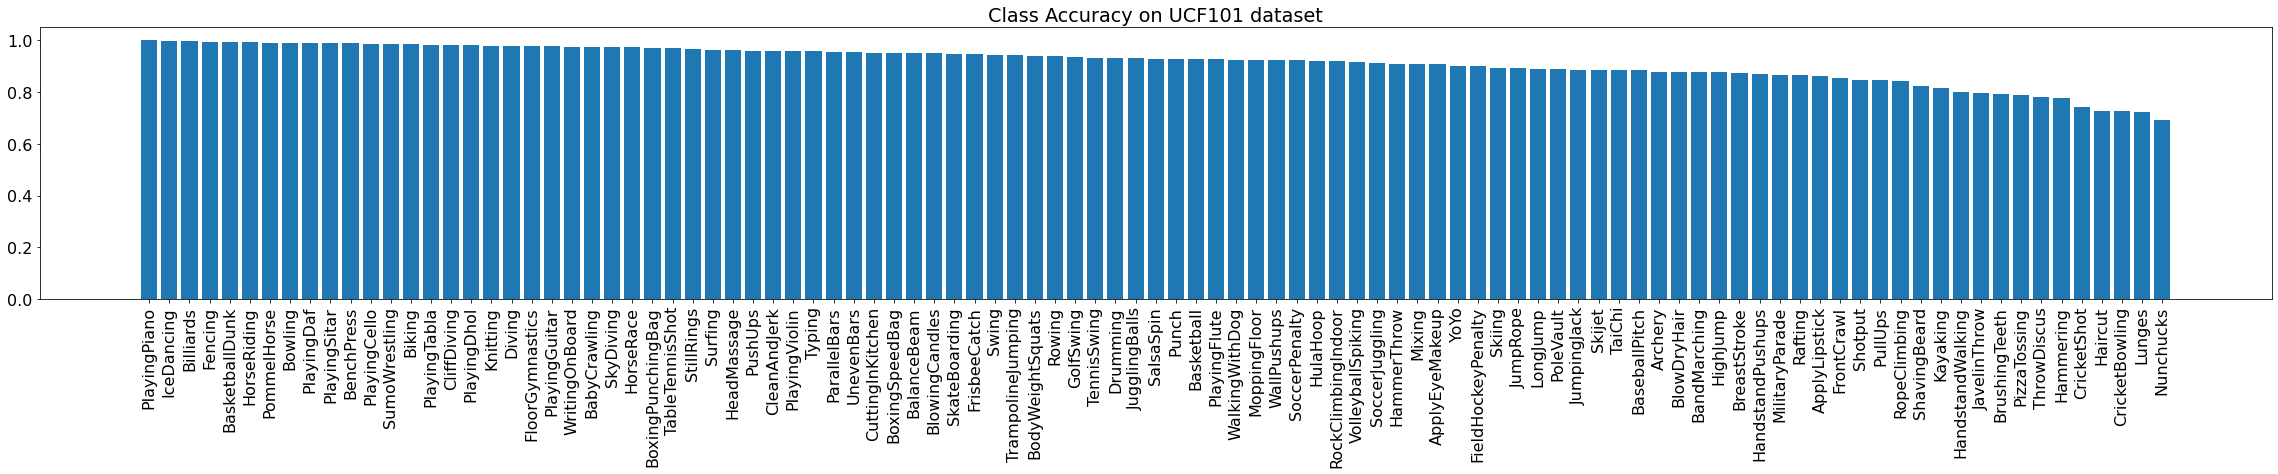

In [111]:
plt.rcParams['font.size'] = 16

for dataset, size in zip(datasets, [[20, 5], [100, 5], [40, 5]]):
    labels = [x.strip() for x in open(datasets_folder[dataset]+"/label_map_"+dataset+".txt").readlines()]
    sorted_classes = sorted(zip(results[dataset]['mean']['class_accuracy'], labels), key= lambda tup: tup[0], reverse=True)

    plt.rcParams['figure.figsize'] = size
    plt.bar(height=[t[0] for t in sorted_classes], x=[t[1] for t in sorted_classes])
    plt.xticks([t[1] for t in sorted_classes], rotation=90)
    plt.title(f"Class Accuracy on {dataset} dataset")
    plt.show()